# Notebook 09 — Split de datos, validación cruzada y selección de hiperparámetros

En este notebook estudiaremos cómo estimar el desempeño de un modelo y seleccionar hiperparámetros sin utilizar indebidamente el conjunto de prueba.

## Objetivos

Al finalizar el notebook deberías ser capaz de:

- distinguir entre entrenamiento, validación y prueba;
- explicar por qué el conjunto de prueba debe permanecer aislado;
- utilizar `KFold` y `RepeatedKFold`;
- evaluar modelos con `cross_validate`;
- interpretar la media y la variabilidad entre folds;
- construir un `Pipeline` dentro de validación cruzada;
- seleccionar hiperparámetros con `GridSearchCV`;
- comparar `GridSearchCV` y `RandomizedSearchCV`;
- realizar una evaluación final sobre test;
- evitar Data Leakage durante la selección del modelo.

Usaremos un problema sintético de regresión con varias variables.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, loguniform

from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    RepeatedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42

pd.options.display.float_format = "{:,.4f}".format


## 2. Generación de datos sintéticos

Crearemos un problema de regresión con:

- 900 observaciones;
- 12 variables;
- 8 variables informativas;
- ruido aleatorio.

El objetivo no será encontrar el modelo más sofisticado, sino construir un proceso de validación correcto.

In [2]:
X, y, true_coefficients = make_regression(
    n_samples=900,
    n_features=12,
    n_informative=8,
    noise=25,
    coef=True,
    random_state=RANDOM_STATE,
)

feature_names = [
    f"x_{index}"
    for index in range(1, X.shape[1] + 1)
]

X = pd.DataFrame(
    X,
    columns=feature_names,
)

y = pd.Series(
    y,
    name="y",
)

print(X.shape)
X.head()


(900, 12)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,x_11,x_12
0,-0.1832,0.4977,0.6067,3.1099,0.8877,1.9957,0.6659,0.2301,0.5345,1.7952,-0.3207,0.4216
1,0.0868,-1.1040,-0.6627,0.9247,-0.8193,1.2747,-1.4902,-0.8938,-0.5328,-1.1975,0.9554,0.1464
2,-1.8895,0.4255,-0.4462,-0.6526,-2.4239,0.8406,-0.9670,0.7858,-0.4523,0.7604,-1.5839,-0.0477
3,0.7215,-0.9879,-0.7353,-0.5244,0.7575,-1.6566,-0.8469,0.2838,-1.0501,0.6952,1.3705,1.2496
4,-0.6057,-0.7534,2.1573,-0.4879,0.2993,0.6779,0.4600,0.0320,0.7421,1.5615,1.3017,-0.6777


## 3. Entrenamiento, validación y prueba

Una división conceptual común es:

- **train:** estima los parámetros;
- **validation:** compara modelos y selecciona hiperparámetros;
- **test:** produce la evaluación final.

Cuando usamos validación cruzada, los datos de entrenamiento se dividen internamente en folds de entrenamiento y validación.

El test permanece completamente separado.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print(f"Train: {X_train.shape}")
print(f"Test: {X_test.shape}")


Train: (720, 12)
Test: (180, 12)


## 4. Por qué un solo split puede ser inestable

Compararemos el desempeño de un mismo modelo utilizando diferentes semillas en el split.

In [4]:
split_results = []

for seed in range(20):
    X_train_seed, X_valid_seed, y_train_seed, y_valid_seed = (
        train_test_split(
            X_train,
            y_train,
            test_size=0.25,
            random_state=seed,
        )
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=10)),
    ])

    model.fit(
        X_train_seed,
        y_train_seed,
    )

    predictions = model.predict(
        X_valid_seed
    )

    split_results.append({
        "seed": seed,
        "RMSE validación": mean_squared_error(
            y_valid_seed,
            predictions,
        ) ** 0.5,
        "R² validación": r2_score(
            y_valid_seed,
            predictions,
        ),
    })

split_results_df = pd.DataFrame(
    split_results
)

split_results_df


,seed,RMSE validación,R² validación
0,0,97.1840,0.6740
1,1,97.0800,0.6620
2,2,94.9014,0.6652
3,3,88.8746,0.6721
4,4,93.3307,0.6818
5,5,94.9205,0.6767
6,6,101.2985,0.6759
7,7,98.2855,0.6836
8,8,99.3945,0.6816
9,9,96.1915,0.6936


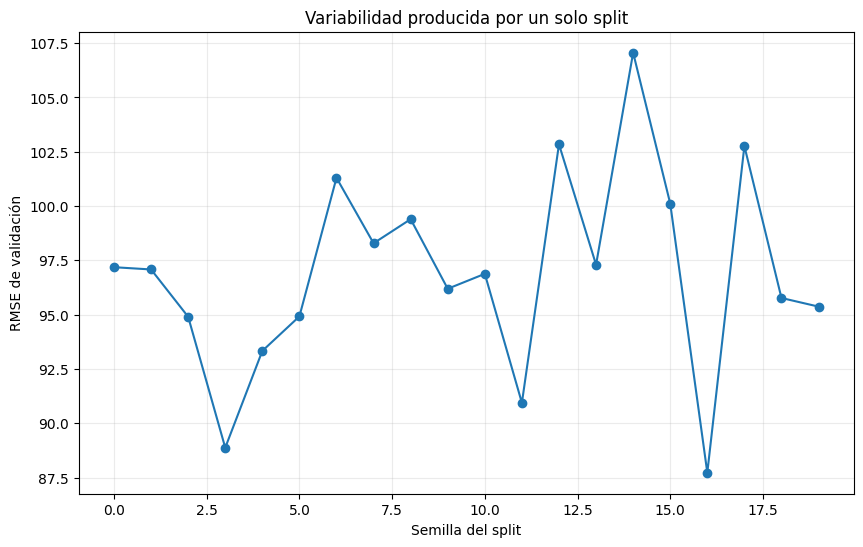

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(
    split_results_df["seed"],
    split_results_df["RMSE validación"],
    marker="o",
)
plt.xlabel("Semilla del split")
plt.ylabel("RMSE de validación")
plt.title("Variabilidad producida por un solo split")
plt.grid(alpha=0.25)
plt.show()


El resultado cambia porque cada split contiene observaciones distintas.

La validación cruzada reduce la dependencia respecto de una sola partición.

## 5. K-Fold Cross Validation

En \(K\)-Fold:

1. se divide el conjunto de entrenamiento en \(K\) partes;
2. cada fold se utiliza una vez como validación;
3. los demás folds se usan para entrenar;
4. se promedian los resultados.

El test no participa.

In [6]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=10)),
])

cv_results = cross_validate(
    estimator=ridge_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    return_train_score=True,
)

cv_results.keys()


dict_keys(['fit_time', 'score_time', 'test_mae', 'train_mae', 'test_rmse', 'train_rmse', 'test_r2', 'train_r2'])

In [7]:
fold_table = pd.DataFrame({
    "Fold": np.arange(1, 6),
    "RMSE train": -cv_results["train_rmse"],
    "RMSE validación": -cv_results["test_rmse"],
    "MAE validación": -cv_results["test_mae"],
    "R² validación": cv_results["test_r2"],
    "Tiempo de ajuste": cv_results["fit_time"],
})

fold_table


,Fold,RMSE train,RMSE validación,MAE validación,R² validación,Tiempo de ajuste
0,1,23.3074,27.8942,21.4924,0.9704,0.0029
1,2,24.5011,23.2604,17.9380,0.9824,0.0016
2,3,24.3768,23.3217,19.2004,0.9798,0.0023
3,4,24.1319,24.3381,20.0812,0.9777,0.0018
4,5,24.3602,23.9359,19.2998,0.9787,0.0017


In [8]:
cv_summary = pd.DataFrame({
    "Métrica": [
        "RMSE validación",
        "MAE validación",
        "R² validación",
    ],
    "Media": [
        (-cv_results["test_rmse"]).mean(),
        (-cv_results["test_mae"]).mean(),
        cv_results["test_r2"].mean(),
    ],
    "Desviación estándar": [
        (-cv_results["test_rmse"]).std(),
        (-cv_results["test_mae"]).std(),
        cv_results["test_r2"].std(),
    ],
})

cv_summary


,Métrica,Media,Desviación estándar
0,RMSE validación,24.5500,1.7191
1,MAE validación,19.6024,1.1683
2,R² validación,0.9778,0.0040


La media resume el desempeño esperado.  
La desviación estándar refleja estabilidad entre folds.

Dos modelos con medias similares pueden diferir en estabilidad.

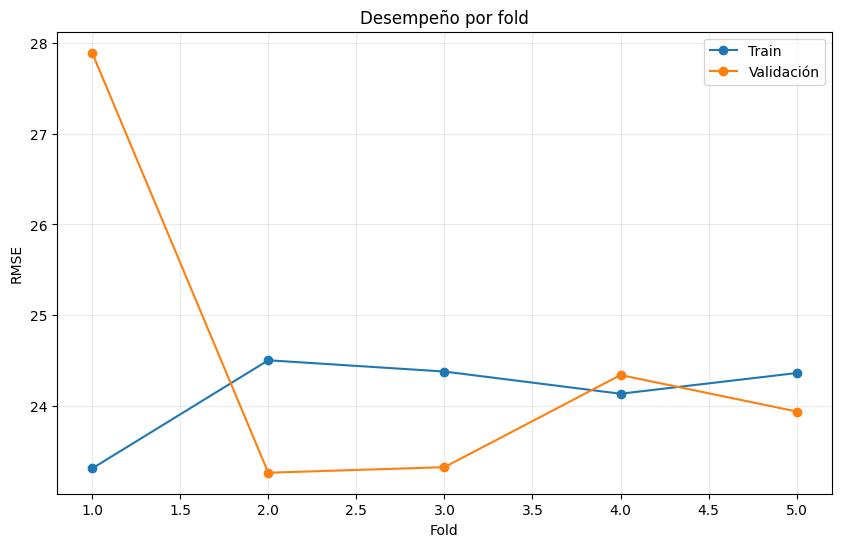

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    fold_table["Fold"],
    fold_table["RMSE train"],
    marker="o",
    label="Train",
)

plt.plot(
    fold_table["Fold"],
    fold_table["RMSE validación"],
    marker="o",
    label="Validación",
)

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("Desempeño por fold")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 6. Repeated K-Fold

Repeated K-Fold repite la validación cruzada con distintas particiones.

Esto permite obtener una estimación más estable, a costa de mayor tiempo de cómputo.

In [10]:
repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=4,
    random_state=RANDOM_STATE,
)

repeated_results = cross_validate(
    estimator=ridge_pipeline,
    X=X_train,
    y=y_train,
    cv=repeated_cv,
    scoring="neg_root_mean_squared_error",
)

repeated_rmse = -repeated_results["test_score"]

pd.Series(
    repeated_rmse,
    name="RMSE validación",
).describe()


count   20.0000
mean    24.6321
std      1.6277
min     20.8495
25%     23.6566
50%     24.5045
75%     25.3902
max     27.8942
Name: RMSE validación, dtype: float64

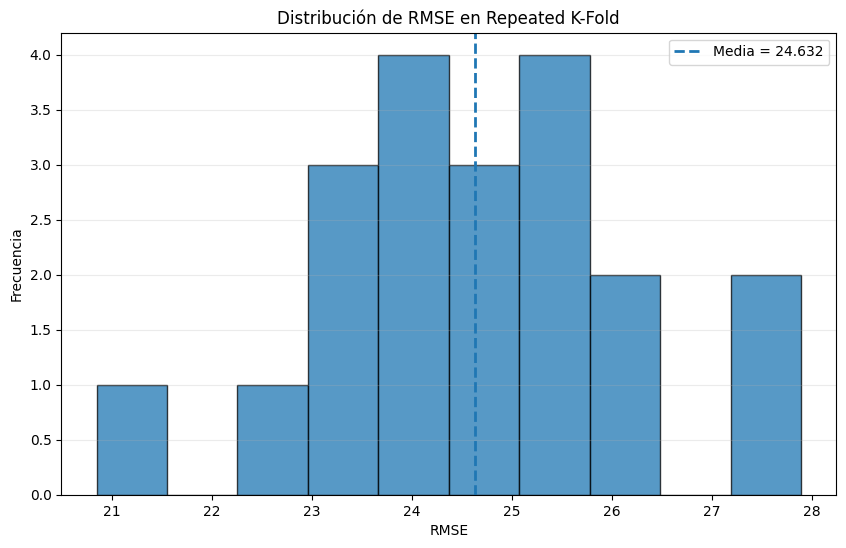

In [11]:
plt.figure(figsize=(10, 6))
plt.hist(
    repeated_rmse,
    bins=10,
    edgecolor="black",
    alpha=0.75,
)
plt.axvline(
    repeated_rmse.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {repeated_rmse.mean():.3f}",
)
plt.xlabel("RMSE")
plt.ylabel("Frecuencia")
plt.title("Distribución de RMSE en Repeated K-Fold")
plt.legend()
plt.grid(axis="y", alpha=0.25)
plt.show()


## 7. Comparación de modelos mediante validación cruzada

Compararemos Ridge, KNN y árbol de decisión con el mismo esquema de validación.

In [12]:
candidate_models = {
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=10)),
    ]),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=12,
            weights="distance",
        )),
    ]),
    "Árbol": DecisionTreeRegressor(
        max_depth=6,
        min_samples_leaf=8,
        random_state=RANDOM_STATE,
    ),
}

model_cv_rows = []

for model_name, model in candidate_models.items():
    results = cross_validate(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="neg_root_mean_squared_error",
        return_train_score=True,
    )

    model_cv_rows.append({
        "Modelo": model_name,
        "RMSE train medio": (
            -results["train_score"]
        ).mean(),
        "RMSE validación medio": (
            -results["test_score"]
        ).mean(),
        "Desv. RMSE validación": (
            -results["test_score"]
        ).std(),
    })

model_cv_table = pd.DataFrame(
    model_cv_rows
)

model_cv_table.sort_values(
    "RMSE validación medio"
)


,Modelo,RMSE train medio,RMSE validación medio,Desv. RMSE validación
0,Ridge,24.1355,24.5500,1.7191
1,KNN,0.0000,95.9488,2.7924
2,Árbol,75.6067,114.2792,2.2211


## 8. Grid Search para KNN

Buscaremos combinaciones de:

- número de vecinos;
- ponderación;
- distancia Manhattan o Euclidiana.

El escalamiento permanece dentro del pipeline para evitar leakage.

In [13]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor()),
])

knn_param_grid = {
    "knn__n_neighbors": [3, 5, 8, 12, 20, 35],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

knn_grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=knn_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True,
)

knn_grid_search.fit(
    X_train,
    y_train,
)

print("Mejores parámetros:")
print(knn_grid_search.best_params_)

print(
    "Mejor RMSE CV:",
    -knn_grid_search.best_score_,
)


Mejores parámetros:
{'knn__n_neighbors': 8, 'knn__p': 2, 'knn__weights': 'distance'}
Mejor RMSE CV: 94.50822559378129


In [14]:
knn_grid_results = pd.DataFrame(
    knn_grid_search.cv_results_
)

knn_grid_summary = knn_grid_results[
    [
        "param_knn__n_neighbors",
        "param_knn__weights",
        "param_knn__p",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()

knn_grid_summary["RMSE train"] = (
    -knn_grid_summary["mean_train_score"]
)
knn_grid_summary["RMSE validación"] = (
    -knn_grid_summary["mean_test_score"]
)

knn_grid_summary.sort_values(
    "rank_test_score"
).head(12)


,param_knn__n_neighbors,param_knn__weights,param_knn__p,mean_train_score,mean_test_score,std_test_score,rank_test_score,RMSE train,RMSE validación
11,8,distance,2,0.0000,-94.5082,3.0782,1,-0.0000,94.5082
7,5,distance,2,0.0000,-95.1955,2.8652,2,-0.0000,95.1955
10,8,uniform,2,-82.8865,-95.2014,3.3440,3,82.8865,95.2014
6,5,uniform,2,-77.5394,-95.6594,2.9059,4,77.5394,95.6594
15,12,distance,2,0.0000,-95.9488,2.7924,5,-0.0000,95.9488
14,12,uniform,2,-88.4062,-96.8382,2.9747,6,88.4062,96.8382
19,20,distance,2,0.0000,-97.3905,2.7310,7,-0.0000,97.3905
3,3,distance,2,0.0000,-98.1008,2.0378,8,-0.0000,98.1008
18,20,uniform,2,-93.3054,-98.2599,2.8958,9,93.3054,98.2599
2,3,uniform,2,-69.6664,-98.3850,1.9040,10,69.6664,98.3850


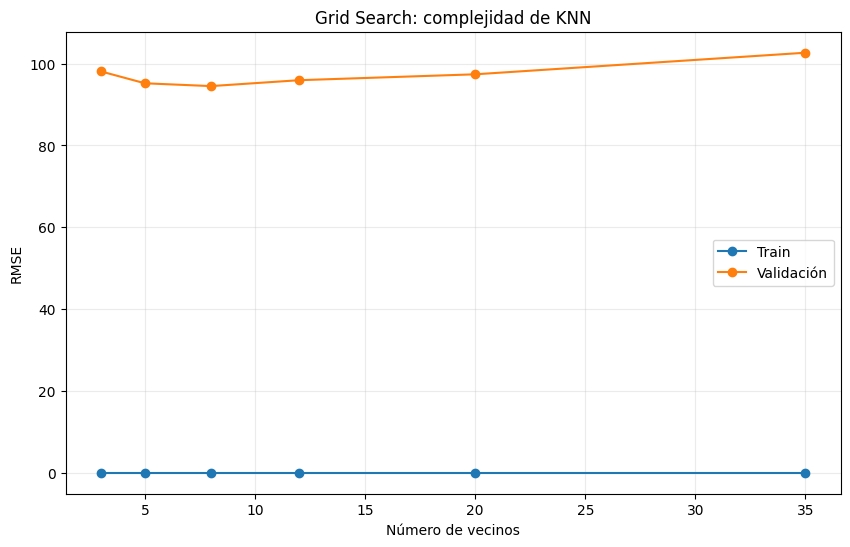

In [15]:
plot_data = (
    knn_grid_summary
    .query(
        "param_knn__weights == 'distance' "
        "and param_knn__p == 2"
    )
    .sort_values("param_knn__n_neighbors")
)

plt.figure(figsize=(10, 6))

plt.plot(
    plot_data["param_knn__n_neighbors"],
    plot_data["RMSE train"],
    marker="o",
    label="Train",
)

plt.plot(
    plot_data["param_knn__n_neighbors"],
    plot_data["RMSE validación"],
    marker="o",
    label="Validación",
)

plt.xlabel("Número de vecinos")
plt.ylabel("RMSE")
plt.title("Grid Search: complejidad de KNN")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 9. Randomized Search para Ridge

Grid Search evalúa todas las combinaciones especificadas.

Randomized Search toma una muestra del espacio de hiperparámetros. Resulta útil cuando:

- hay muchas dimensiones;
- los rangos son amplios;
- el presupuesto computacional es limitado.

In [16]:
ridge_search_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge()),
])

ridge_parameter_distributions = {
    "ridge__alpha": loguniform(
        1e-4,
        1e4,
    ),
}

ridge_random_search = RandomizedSearchCV(
    estimator=ridge_search_pipeline,
    param_distributions=ridge_parameter_distributions,
    n_iter=35,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    return_train_score=True,
)

ridge_random_search.fit(
    X_train,
    y_train,
)

print("Mejor alpha:")
print(ridge_random_search.best_params_)

print(
    "Mejor RMSE CV:",
    -ridge_random_search.best_score_,
)


Mejor alpha:
{'ridge__alpha': np.float64(0.00014610865886287216)}
Mejor RMSE CV: 24.348263715635603


In [17]:
ridge_random_results = pd.DataFrame(
    ridge_random_search.cv_results_
)

ridge_random_summary = ridge_random_results[
    [
        "param_ridge__alpha",
        "mean_train_score",
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
    ]
].copy()

ridge_random_summary["RMSE train"] = (
    -ridge_random_summary["mean_train_score"]
)
ridge_random_summary["RMSE validación"] = (
    -ridge_random_summary["mean_test_score"]
)

ridge_random_summary.sort_values(
    "rank_test_score"
).head(10)


,param_ridge__alpha,mean_train_score,mean_test_score,std_test_score,rank_test_score,RMSE train,RMSE validación
10,0.0001,-23.9443,-24.3483,1.7046,1,23.9443,24.3483
29,0.0002,-23.9443,-24.3483,1.7046,2,23.9443,24.3483
6,0.0003,-23.9443,-24.3483,1.7046,3,23.9443,24.3483
32,0.0003,-23.9443,-24.3483,1.7046,4,23.9443,24.3483
21,0.0013,-23.9443,-24.3483,1.7046,5,23.9443,24.3483
5,0.0018,-23.9443,-24.3483,1.7046,6,23.9443,24.3483
4,0.0018,-23.9443,-24.3483,1.7046,7,23.9443,24.3483
31,0.0023,-23.9443,-24.3483,1.7046,8,23.9443,24.3483
14,0.0028,-23.9443,-24.3483,1.7046,9,23.9443,24.3483
15,0.0029,-23.9443,-24.3483,1.7046,10,23.9443,24.3483


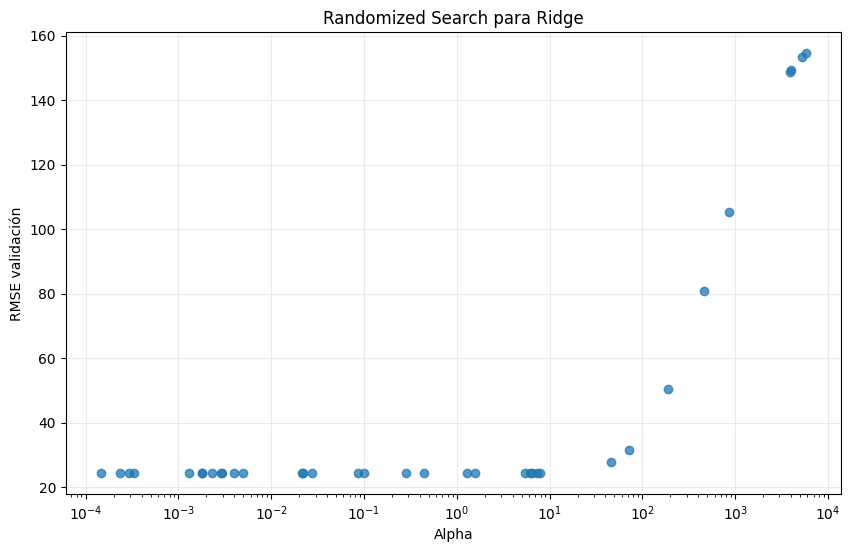

In [18]:
sorted_ridge = ridge_random_summary.sort_values(
    "param_ridge__alpha"
)

plt.figure(figsize=(10, 6))

plt.scatter(
    sorted_ridge["param_ridge__alpha"],
    sorted_ridge["RMSE validación"],
    alpha=0.75,
)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE validación")
plt.title("Randomized Search para Ridge")
plt.grid(alpha=0.25)
plt.show()


## 10. Selección final y evaluación sobre test

Hasta este punto, el test no se ha utilizado para seleccionar hiperparámetros.

Compararemos los mejores modelos encontrados y elegiremos uno usando sus resultados de validación cruzada.

In [19]:
search_comparison = pd.DataFrame({
    "Modelo": [
        "Mejor KNN",
        "Mejor Ridge",
    ],
    "RMSE CV": [
        -knn_grid_search.best_score_,
        -ridge_random_search.best_score_,
    ],
})

search_comparison


,Modelo,RMSE CV
0,Mejor KNN,94.5082
1,Mejor Ridge,24.3483


In [20]:
if (
    -knn_grid_search.best_score_
    < -ridge_random_search.best_score_
):
    final_model_name = "KNN"
    final_model = knn_grid_search.best_estimator_
else:
    final_model_name = "Ridge"
    final_model = ridge_random_search.best_estimator_

print(f"Modelo seleccionado: {final_model_name}")


Modelo seleccionado: Ridge


In [21]:
final_test_predictions = final_model.predict(
    X_test
)

final_test_metrics = pd.DataFrame({
    "Métrica": ["MAE", "RMSE", "R²"],
    "Valor test": [
        mean_absolute_error(
            y_test,
            final_test_predictions,
        ),
        mean_squared_error(
            y_test,
            final_test_predictions,
        ) ** 0.5,
        r2_score(
            y_test,
            final_test_predictions,
        ),
    ],
})

final_test_metrics


,Métrica,Valor test
0,MAE,20.8425
1,RMSE,26.4677
2,R²,0.9773


La evaluación de test es la estimación final del desempeño fuera de muestra.

No debe utilizarse para volver a modificar el modelo. Si se continúa iterando con base en test, deja de funcionar como evaluación independiente.

## 11. Data Leakage dentro de validación cruzada

### Incorrecto

```python
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
cross_validate(model, X_scaled, y_train)
```

El escalador utilizó información de todos los folds antes de validar.

### Correcto

```python
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor()),
])

cross_validate(pipeline, X_train, y_train)
```

En cada fold, el escalador se ajusta únicamente con la parte de entrenamiento correspondiente.

## 12. ¿Cuántos folds usar?

No existe una respuesta universal.

Valores comunes:

- 5 folds;
- 10 folds.

Más folds:

- usan más datos para entrenar en cada iteración;
- aumentan el costo;
- pueden incrementar la correlación entre estimaciones.

La decisión depende del tamaño de muestra y del presupuesto computacional.

In [22]:
fold_number_results = []

for n_splits in [3, 5, 10, 15]:
    cv_scheme = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    results = cross_validate(
        estimator=ridge_pipeline,
        X=X_train,
        y=y_train,
        cv=cv_scheme,
        scoring="neg_root_mean_squared_error",
    )

    rmse_values = -results["test_score"]

    fold_number_results.append({
        "Número de folds": n_splits,
        "RMSE medio": rmse_values.mean(),
        "Desviación RMSE": rmse_values.std(),
        "Tiempo total": results["fit_time"].sum(),
    })

fold_number_table = pd.DataFrame(
    fold_number_results
)

fold_number_table


,Número de folds,RMSE medio,Desviación RMSE,Tiempo total
0,3,24.7500,2.0641,0.0044
1,5,24.5500,1.7191,0.0060
2,10,24.4523,2.2657,0.0119
3,15,24.2877,3.6831,0.0168


## 13. Errores frecuentes

1. Seleccionar hiperparámetros con test.
2. Ajustar preprocesamiento antes de validación cruzada.
3. Comparar modelos usando folds distintos.
4. Reportar solo la media e ignorar la variabilidad.
5. Usar demasiadas combinaciones sin criterio.
6. Confundir parámetros con hiperparámetros.
7. Optimizar una métrica distinta de la relevante para negocio.
8. Reutilizar test después de múltiples decisiones.
9. No fijar semillas cuando se requiere reproducibilidad.
10. Suponer que el mejor score de CV garantiza desempeño futuro idéntico.

## 14. Experimentos sugeridos

### Experimento 1

Compara 3, 5 y 10 folds.

### Experimento 2

Aumenta `n_repeats` en `RepeatedKFold`.

### Experimento 3

Amplía la malla de KNN.

### Experimento 4

Agrega un árbol de decisión a `GridSearchCV`.

### Experimento 5

Optimiza MAE en lugar de RMSE.

### Experimento 6

Compara `GridSearchCV` y `RandomizedSearchCV` con el mismo presupuesto de evaluaciones.

### Experimento 7

Ajusta el escalador fuera del pipeline y compara los resultados para discutir leakage.

### Experimento 8

Repite todo el proceso con otra semilla en el split train-test.

### Experimento 9

Usa varias métricas en `GridSearchCV` y selecciona una mediante `refit`.

### Experimento 10

Mide el tiempo de cómputo al aumentar el tamaño de la búsqueda.

## 15. Resumen

En este notebook:

- separamos train y test;
- observamos la inestabilidad de un solo split;
- utilizamos K-Fold y Repeated K-Fold;
- evaluamos múltiples métricas;
- comparamos modelos con el mismo esquema;
- seleccionamos hiperparámetros con Grid Search;
- exploramos Randomized Search;
- mantuvimos el preprocesamiento dentro del pipeline;
- realizamos una evaluación final sobre test.

La validación correcta no es un paso administrativo. Es el mecanismo que evita seleccionar modelos basados en resultados accidentales o contaminados.